# Bag of Words — da implementação manual ao scikit-learn

**Objetivo**: entender, na prática, como um texto se transforma em vetor numérico e por que isso
basta para classificar documentos com boa acurácia.

**Corpus**: [B2W-Reviews01](https://huggingface.co/datasets/vladjr/B2W-Reviews01) — 132.373 avaliações
de produtos em português do site Americanas, cada uma com nota de 1 a 5.

**Roteiro**

| Seção | Conteúdo |
|---|---|
| 1 | Carregar e preparar o corpus |
| 2 | Pré-processamento passo a passo (normalizar → tokenizar → remover *stopwords*) |
| 3 | Vocabulário e matriz de contagem **na mão** |
| 4 | TF-IDF **na mão**, com as fórmulas abertas |
| 5 | Conferir contra `CountVectorizer` / `TfidfVectorizer` |
| 6 | Classificação: Naive Bayes e Regressão Logística |
| 7 | Variações: n-gramas, `min_df`, `max_df` |
| 8 | Limitações do modelo e exercícios |

> A primeira execução baixa o dataset (~60 MB) para `data/`. As seguintes usam o cache.

In [1]:
import os
import re
import unicodedata
from collections import Counter
from pathlib import Path

# Cache dos datasets dentro do projeto (ignorado pelo git).
PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "bag_of_words" else Path.cwd()
os.environ.setdefault("HF_HOME", str(PROJECT_DIR / "data" / "hf"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

pd.set_option("display.max_colwidth", 90)
%matplotlib inline

print("projeto:", PROJECT_DIR)
print("cache HF:", os.environ["HF_HOME"])

projeto: /home/rafaelsousa/PycharmProjects/Especializacao-NLP
cache HF: /home/rafaelsousa/PycharmProjects/Especializacao-NLP/data/hf


## 1. O corpus

As notas vão de 1 a 5. Transformamos isso num problema binário:

- **negativo** — notas 1 e 2
- **positivo** — notas 4 e 5
- nota 3 é descartada: é ambígua e só adiciona ruído ao exercício

Depois sorteamos uma amostra **balanceada**. Duas razões: o corpus completo é desbalanceado
(mais de 80 mil avaliações positivas contra 35 mil negativas), e uma amostra menor mantém o
notebook rápido de rodar. Com classes balanceadas, a acurácia passa a ser uma métrica honesta —
o chute constante acerta 50%.

In [2]:
from datasets import load_dataset

raw = load_dataset("vladjr/B2W-Reviews01", split="train")
df = raw.to_pandas()[["review_text", "overall_rating", "product_name"]]
print("linhas brutas:", len(df))

# Remove textos vazios/nulos e a nota neutra.
df = df[df["review_text"].notna()]
df = df[df["review_text"].str.strip().str.len() > 0]
df = df[df["overall_rating"] != 3]
df["sentimento"] = np.where(df["overall_rating"] >= 4, "positivo", "negativo")

print("apos limpeza:", len(df))
df["sentimento"].value_counts()

linhas brutas: 132373
apos limpeza: 113088


sentimento
positivo    79316
negativo    33772
Name: count, dtype: int64

In [3]:
N_POR_CLASSE = 3_000

por_classe = [
    grupo.sample(N_POR_CLASSE, random_state=RANDOM_STATE)
    for _, grupo in df.groupby("sentimento")
]
amostra = (
    pd.concat(por_classe)
    .sample(frac=1, random_state=RANDOM_STATE)  # embaralha
    .reset_index(drop=True)
)

print(amostra["sentimento"].value_counts().to_string())
amostra.head(5)

sentimento
negativo    3000
positivo    3000


,review_text,overall_rating,product_name,sentimento
0,"A entrega da americanas foi num prazo menor do que a previsão do site, porém é o segun...",1,Aspirador de Pó Mondial AP-18 Next Black 2200 - 1500W,negativo
1,"O produto chegou antes da data informada, fica lindo para decorar o ambiente.",5,Espelho Corações Em Acrílico - Kit 12 Peças,positivo
2,Quem compra Epson sabe o lixo que leva para dentro de casa ou trabalho.,1,Kit 4 Refil 2 Litros Para Ecotank e Epson L220 L300 L350 L355 L365 L375 L385 L395,negativo
3,"PRODUTO ANUNCIADO 300ML, PRODUTO QUE FOI ENTREGUE 250ML. O MESMO NAO CONDIZ COM O ANUN...",1,Itallian Hairtech Trivitt Fluido Para Escova Nº 6 - 300ml,negativo
4,"Reinos de Ferro é uma ótima aventura rpj para jogar com os amigos, sua mecânica para o...",5,Livro - Reinos de Ferro,positivo


In [4]:
from sklearn.model_selection import train_test_split

X_train_txt, X_test_txt, y_train, y_test = train_test_split(
    amostra["review_text"].tolist(),
    amostra["sentimento"].tolist(),
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=amostra["sentimento"],
)

print(f"treino: {len(X_train_txt)} | teste: {len(X_test_txt)}")
print("\nExemplo negativo:")
print(next(t for t, y in zip(X_train_txt, y_train) if y == "negativo")[:300])
print("\nExemplo positivo:")
print(next(t for t, y in zip(X_train_txt, y_train) if y == "positivo")[:300])

treino: 4500 | teste: 1500

Exemplo negativo:
cancelei a compra dia 06/12 e até hoje (11 janeiro)  nao reembolsaram o valor pago.

Exemplo positivo:
Entrega super rápida .   Parabéns pela agilidade na entrega e qualidade no produto .


## 2. Pré-processamento

Bag of Words ignora ordem: o documento vira um saco de palavras. Antes de contar, precisamos
decidir **o que conta como a mesma palavra**. Cada decisão abaixo reduz o vocabulário e, com ele,
a esparsidade da matriz:

1. **Minúsculas** — `Ótimo` e `ótimo` passam a ser o mesmo termo.
2. **Remover acentos** — em avaliações de e-commerce a grafia é irregular (`otimo`, `ótimo`,
   `NÃO`, `nao`). Normalizar unifica esses casos. Em outros domínios isso pode ser prejudicial,
   já que apaga distinções reais (`e` vs. `é`).
3. **Tokenizar** — quebrar em palavras com uma expressão regular que só aceita letras.
   Pontuação e números saem junto.
4. **Remover *stopwords*** — artigos, preposições e conectivos aparecem em quase todo documento,
   então quase não ajudam a separar as classes.

> **Atenção**: a lista de *stopwords* do spaCy inclui `não`, `nunca`, `nada`. Para análise de
> sentimento isso é ruim — "não gostei" viraria "gostei". Mantemos as negações de fora da lista
> de remoção, e a seção 8 mostra que mesmo assim o BoW erra com negação.

In [5]:
from spacy.lang.pt.stop_words import STOP_WORDS

NEGACOES = {"nao", "nunca", "nem", "nada", "jamais", "sem"}

def remover_acentos(texto: str) -> str:
    '''Decompõe os caracteres e descarta os diacríticos (ó -> o, ç -> c).'''
    decomposto = unicodedata.normalize("NFKD", texto)
    return "".join(c for c in decomposto if not unicodedata.combining(c))

STOPWORDS_PT = {remover_acentos(w) for w in STOP_WORDS} - NEGACOES

TOKEN_RE = re.compile(r"[a-z]+")

def normalizar(texto: str) -> str:
    return remover_acentos(texto.lower())

def tokenizar(texto: str) -> list[str]:
    '''Normaliza, extrai palavras e descarta stopwords e tokens de 1 letra.'''
    palavras = TOKEN_RE.findall(normalizar(texto))
    return [p for p in palavras if p not in STOPWORDS_PT and len(p) > 1]

print(f"{len(STOPWORDS_PT)} stopwords (negações preservadas)")
print("amostra:", sorted(STOPWORDS_PT)[:12])

398 stopwords (negações preservadas)
amostra: ['a', 'acerca', 'ademais', 'adeus', 'agora', 'ai', 'ainda', 'alem', 'algo', 'algumas', 'alguns', 'ali']


In [6]:
exemplo = X_train_txt[0]

print("original:  ", exemplo[:200])
print("\nnormalizado:", normalizar(exemplo)[:200])
print("\ntokens:     ", tokenizar(exemplo)[:25])

original:   Entrega super rápida .   Parabéns pela agilidade na entrega e qualidade no produto .

normalizado: entrega super rapida .   parabens pela agilidade na entrega e qualidade no produto .

tokens:      ['entrega', 'super', 'rapida', 'parabens', 'agilidade', 'entrega', 'qualidade', 'produto']


In [7]:
# Tokenizamos uma vez e reaproveitamos nas próximas seções.
docs_train = [tokenizar(t) for t in X_train_txt]
docs_test = [tokenizar(t) for t in X_test_txt]

tamanhos = [len(d) for d in docs_train]
print(f"tokens por documento — mediana {np.median(tamanhos):.0f}, "
      f"média {np.mean(tamanhos):.1f}, máximo {max(tamanhos)}")
print(f"tipos distintos no treino: {len({t for d in docs_train for t in d}):,}")

tokens por documento — mediana 9, média 13.1, máximo 250
tipos distintos no treino: 8,506


## 3. Vocabulário e matriz de contagem, na mão

O vocabulário é o mapa `termo -> índice de coluna`. Cada documento vira uma linha com a contagem
de cada termo.

Aplicamos um corte de **frequência de documento** (`min_df`): termos que aparecem em menos de
`min_df` documentos são descartados. São na maioria erros de digitação e nomes de produto — geram
milhares de colunas que o modelo não consegue aprender. O corte é calculado **só no treino**;
usar o teste aqui seria vazamento de dados.

In [8]:
def construir_vocabulario(docs: list[list[str]], min_df: int = 3) -> dict[str, int]:
    '''Mapeia termo -> índice, mantendo só termos presentes em >= min_df documentos.'''
    freq_doc = Counter()
    for doc in docs:
        freq_doc.update(set(doc))  # set: conta documentos, não ocorrências
    termos = sorted(t for t, n in freq_doc.items() if n >= min_df)
    return {termo: i for i, termo in enumerate(termos)}

vocabulario = construir_vocabulario(docs_train, min_df=3)
print(f"vocabulário: {len(vocabulario):,} termos")
print("primeiros:", list(vocabulario)[:10])

vocabulário: 2,592 termos
primeiros: ['abaixo', 'aberta', 'aberto', 'abertura', 'abre', 'abri', 'abril', 'abrir', 'abriu', 'absolutamente']


In [9]:
def matriz_contagem(docs: list[list[str]], vocab: dict[str, int]) -> np.ndarray:
    '''Matriz densa (n_documentos x n_termos) com a contagem de cada termo.'''
    X = np.zeros((len(docs), len(vocab)), dtype=np.int64)
    for i, doc in enumerate(docs):
        for termo, n in Counter(doc).items():
            j = vocab.get(termo)  # termos fora do vocabulário são ignorados (OOV)
            if j is not None:
                X[i, j] = n
    return X

X_train_cont = matriz_contagem(docs_train, vocabulario)
X_test_cont = matriz_contagem(docs_test, vocabulario)

print("shape treino:", X_train_cont.shape)
ocupadas = np.count_nonzero(X_train_cont)
print(f"células não-zero: {ocupadas:,} de {X_train_cont.size:,} "
      f"({100 * ocupadas / X_train_cont.size:.2f}%)")
print(f"memória densa: {X_train_cont.nbytes / 1e6:.1f} MB")

shape treino: (4500, 2592)
células não-zero: 46,390 de 11,664,000 (0.40%)
memória densa: 93.3 MB


A matriz é quase toda zero — daí o scikit-learn usar matrizes esparsas, que guardam
apenas as posições preenchidas. Aqui mantemos densa para poder inspecionar os números.

In [10]:
# Como a matriz "enxerga" um documento.
idx = 0
linha = X_train_cont[idx]
termos_idx = np.nonzero(linha)[0]
inverso = {j: t for t, j in vocabulario.items()}

print("texto:", X_train_txt[idx][:200], "\n")
pd.DataFrame(
    {"termo": [inverso[j] for j in termos_idx], "contagem": linha[termos_idx]}
).sort_values("contagem", ascending=False).head(12)

texto: Entrega super rápida .   Parabéns pela agilidade na entrega e qualidade no produto . 



,termo,contagem
1,entrega,2
0,agilidade,1
2,parabens,1
3,produto,1
4,qualidade,1
5,rapida,1
6,super,1


In [11]:
# Termos mais frequentes por classe: primeiro sinal de que BoW separa as classes.
y_train_arr = np.array(y_train)
total_pos = X_train_cont[y_train_arr == "positivo"].sum(axis=0)
total_neg = X_train_cont[y_train_arr == "negativo"].sum(axis=0)
termos = np.array(list(vocabulario))

top = pd.DataFrame({
    "positivo": termos[np.argsort(-total_pos)[:15]],
    "freq_pos": np.sort(total_pos)[::-1][:15],
    "negativo": termos[np.argsort(-total_neg)[:15]],
    "freq_neg": np.sort(total_neg)[::-1][:15],
})
top

,positivo,freq_pos,negativo,freq_neg
0,produto,1101,nao,3058
1,recomendo,554,produto,1587
2,entrega,452,recebi,475
3,nao,426,comprei,447
4,excelente,363,americanas,409
5,qualidade,351,veio,330
6,otimo,349,entrega,316
7,prazo,343,dia,299
8,chegou,319,compra,275
9,super,278,pra,273


## 4. TF-IDF, na mão

Contagem pura tem dois problemas: documentos longos dominam, e termos onipresentes (`produto`,
`compra`) pesam tanto quanto termos discriminativos. TF-IDF corrige os dois.

**TF** (*term frequency*) — quanto o termo aparece no documento. Usamos a contagem bruta, como o
scikit-learn.

**IDF** (*inverse document frequency*) — quão raro o termo é no corpus. Na variante `smooth_idf`
do scikit-learn:

$$\mathrm{idf}(t) = \ln\!\left(\frac{1 + n}{1 + \mathrm{df}(t)}\right) + 1$$

onde $n$ é o número de documentos e $\mathrm{df}(t)$ quantos contêm $t$. Os `+1` evitam divisão por
zero, e o `+1` final garante que nenhum termo seja zerado por completo.

**Peso** — $\mathrm{tfidf}(t, d) = \mathrm{tf}(t, d) \times \mathrm{idf}(t)$, e cada linha é
normalizada em L2 (dividida pela própria norma), de modo que o tamanho do documento deixe de
importar.

In [12]:
def calcular_idf(X_contagem: np.ndarray) -> np.ndarray:
    '''IDF suavizado, na mesma convenção do TfidfTransformer(smooth_idf=True).'''
    n_docs = X_contagem.shape[0]
    df_termo = np.count_nonzero(X_contagem, axis=0)
    return np.log((1 + n_docs) / (1 + df_termo)) + 1

def aplicar_tfidf(X_contagem: np.ndarray, idf: np.ndarray) -> np.ndarray:
    X = X_contagem * idf                       # tf * idf
    normas = np.linalg.norm(X, axis=1, keepdims=True)
    normas[normas == 0] = 1                    # linha vazia continua vazia
    return X / normas                          # normalização L2

idf = calcular_idf(X_train_cont)               # aprendido apenas no treino
X_train_tfidf = aplicar_tfidf(X_train_cont, idf)
X_test_tfidf = aplicar_tfidf(X_test_cont, idf)

pd.DataFrame({
    "menor_idf (termo comum)": termos[np.argsort(idf)[:8]],
    "idf_baixo": np.sort(idf)[:8].round(3),
    "maior_idf (termo raro)": termos[np.argsort(-idf)[:8]],
    "idf_alto": np.sort(idf)[::-1][:8].round(3),
})

,menor_idf (termo comum),idf_baixo,maior_idf (termo raro),idf_alto
0,produto,1.738,aceito,8.026
1,nao,1.805,acertei,8.026
2,recomendo,2.805,acessar,8.026
3,entrega,2.874,visao,8.026
4,chegou,3.097,visualizacao,8.026
5,comprei,3.154,visualizar,8.026
6,qualidade,3.180,vo,8.026
7,prazo,3.222,watts,8.026


In [13]:
# O mesmo documento da seção 3, agora com pesos TF-IDF.
linha = X_train_tfidf[idx]
termos_idx = np.nonzero(linha)[0]

print(f"norma L2 da linha: {np.linalg.norm(linha):.6f}\n")
pd.DataFrame(
    {"termo": [inverso[j] for j in termos_idx], "tfidf": linha[termos_idx].round(4)}
).sort_values("tfidf", ascending=False).head(12)

norma L2 da linha: 1.000000



,termo,tfidf
0,agilidade,0.5619
1,entrega,0.4769
2,parabens,0.3956
5,rapida,0.3365
6,super,0.3110
4,qualidade,0.2638
3,produto,0.1442


## 5. Conferindo com o scikit-learn

Hora de validar. Passamos a nossa função `tokenizar` como `analyzer` para o `CountVectorizer`:
assim ele usa exatamente o mesmo pré-processamento e a diferença fica restrita à implementação.
Se as matrizes coincidirem, nossa versão manual está correta.

In [14]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

cv = CountVectorizer(analyzer=tokenizar, min_df=3)
X_cv = cv.fit_transform(X_train_txt)

print("nosso vocabulário:  ", len(vocabulario))
print("vocabulário sklearn:", len(cv.vocabulary_))
print("mesmos termos:", set(cv.vocabulary_) == set(vocabulario))

# As colunas podem estar em outra ordem; reordenamos pelos nomes antes de comparar.
ordem = [cv.vocabulary_[t] for t in vocabulario]
iguais = np.array_equal(X_cv.toarray()[:, ordem], X_train_cont)
print("matrizes de contagem idênticas:", iguais)

nosso vocabulário:   2592
vocabulário sklearn: 2592
mesmos termos: True


matrizes de contagem idênticas: True


In [15]:
tv = TfidfVectorizer(analyzer=tokenizar, min_df=3)  # smooth_idf=True, norm="l2" por padrão
X_tv = tv.fit_transform(X_train_txt)

ordem = [tv.vocabulary_[t] for t in vocabulario]
print("IDF igual:  ", np.allclose(tv.idf_[ordem], idf))
print("TF-IDF igual:", np.allclose(X_tv.toarray()[:, ordem], X_train_tfidf))

# Checagem explícita: qualquer divergência interrompe o notebook.
assert iguais, "matriz de contagem divergiu do CountVectorizer"
assert np.allclose(X_tv.toarray()[:, ordem], X_train_tfidf), "TF-IDF divergiu do TfidfVectorizer"
print("\nImplementação manual confere com o scikit-learn.")

IDF igual:   True


TF-IDF igual: True



Implementação manual confere com o scikit-learn.


## 6. Classificação

Com os vetores prontos, dois classificadores clássicos para BoW:

- **Multinomial Naive Bayes** — modela a contagem de cada termo por classe. Rápido, e uma
  baseline forte em texto.
- **Regressão Logística** — aprende um peso por termo. Um pouco melhor em geral, e os pesos são
  diretamente interpretáveis (seção 7).

Treinamos com as **nossas** matrizes, para ficar claro que o resultado vem do BoW que construímos.

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report
from sklearn.naive_bayes import MultinomialNB

modelos = {
    "NaiveBayes (contagem)": (MultinomialNB(), X_train_cont, X_test_cont),
    "NaiveBayes (tfidf)": (MultinomialNB(), X_train_tfidf, X_test_tfidf),
    "LogReg (tfidf)": (LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
                       X_train_tfidf, X_test_tfidf),
}

resultados = {}
for nome, (modelo, Xtr, Xte) in modelos.items():
    modelo.fit(Xtr, y_train)
    pred = modelo.predict(Xte)
    resultados[nome] = accuracy_score(y_test, pred)
    print(f"{nome:24s} acurácia = {resultados[nome]:.4f}")

NaiveBayes (contagem)    acurácia = 0.9160
NaiveBayes (tfidf)       acurácia = 0.9153


LogReg (tfidf)           acurácia = 0.9213


In [17]:
melhor_nome = max(resultados, key=resultados.get)
melhor_modelo, _, Xte_melhor = modelos[melhor_nome]
pred = melhor_modelo.predict(Xte_melhor)

print(f"=== {melhor_nome} ===\n")
print(classification_report(y_test, pred, digits=3))

=== LogReg (tfidf) ===



              precision    recall  f1-score   support

    negativo      0.919     0.924     0.922       750
    positivo      0.924     0.919     0.921       750

    accuracy                          0.921      1500
   macro avg      0.921     0.921     0.921      1500
weighted avg      0.921     0.921     0.921      1500



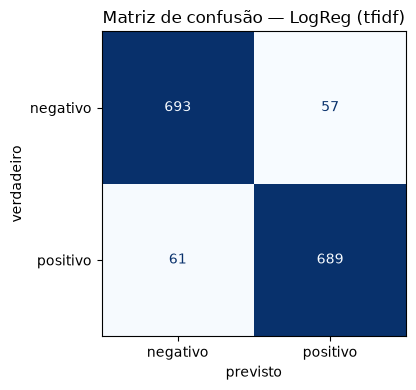

In [18]:
fig, ax = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, pred, cmap="Blues", colorbar=False, ax=ax)
ax.set_title(f"Matriz de confusão — {melhor_nome}")
ax.set_xlabel("previsto")
ax.set_ylabel("verdadeiro")
plt.tight_layout()
plt.show()

## 7. Variações

Três parâmetros mudam bastante o resultado:

- **`ngram_range`** — `(1, 2)` adiciona pares de palavras adjacentes. Recupera parte da ordem
  perdida: "não gostei" passa a ser um termo próprio, além de "não" e "gostei" isolados.
- **`min_df`** — piso de frequência de documento; corta ruído e reduz o vocabulário.
- **`max_df`** — teto; descarta termos presentes em quase todo documento.

In [19]:
from sklearn.pipeline import make_pipeline

configs = [
    {"ngram_range": (1, 1), "min_df": 3},
    {"ngram_range": (1, 2), "min_df": 3},
    {"ngram_range": (1, 2), "min_df": 2, "max_df": 0.5},
    {"ngram_range": (1, 3), "min_df": 2, "max_df": 0.5},
]

linhas = []
for cfg in configs:
    pipe = make_pipeline(
        TfidfVectorizer(tokenizer=tokenizar, lowercase=False,
                        token_pattern=None, **cfg),
        LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    )
    pipe.fit(X_train_txt, y_train)
    acc = accuracy_score(y_test, pipe.predict(X_test_txt))
    linhas.append({**cfg, "n_features": len(pipe[0].vocabulary_), "acuracia": round(acc, 4)})

pd.DataFrame(linhas).sort_values("acuracia", ascending=False)

,ngram_range,min_df,n_features,acuracia,max_df
1,"(1, 2)",3,4555,0.9307,NaN
2,"(1, 2)",2,8267,0.9260,0.5
3,"(1, 3)",2,9755,0.9247,0.5
0,"(1, 1)",3,2592,0.9213,NaN


### Quais termos o modelo usa

Na Regressão Logística cada termo tem um coeficiente. Como `negativo` vem antes de `positivo` na
ordem alfabética das classes, o scikit-learn trata `positivo` como classe 1: coeficiente positivo
empurra para *positivo*, negativo para *negativo*.

In [20]:
pipe = make_pipeline(
    TfidfVectorizer(tokenizer=tokenizar, lowercase=False, token_pattern=None,
                    ngram_range=(1, 2), min_df=3),
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
)
pipe.fit(X_train_txt, y_train)

nomes = np.array(pipe[0].get_feature_names_out())
coefs = pipe[-1].coef_[0]
print("classes:", pipe[-1].classes_, "-> coeficiente positivo indica", pipe[-1].classes_[1])

ordem = np.argsort(coefs)
pd.DataFrame({
    "termo_negativo": nomes[ordem[:15]],
    "coef_neg": coefs[ordem[:15]].round(3),
    "termo_positivo": nomes[ordem[-15:]][::-1],
    "coef_pos": coefs[ordem[-15:]][::-1].round(3),
})

classes: ['negativo' 'positivo'] -> coeficiente positivo indica positivo


,termo_negativo,coef_neg,termo_positivo,coef_pos
0,nao,-8.898,excelente,5.120
1,nao recomendo,-3.484,otimo,4.608
2,produto nao,-2.456,recomendo,4.415
3,veio,-2.331,otima,3.234
4,defeito,-2.315,super,2.967
5,ruim,-2.300,perfeito,2.865
6,recebi,-2.296,facil,2.750
7,nem,-2.198,gostei,2.708
8,pessimo,-2.017,parabens,2.603
9,pessima,-2.017,expectativas,2.369


## 8. Onde o Bag of Words falha

Quatro sondas escritas à mão para provocar o modelo. As duas primeiras usam quase o mesmo
vocabulário e sentido oposto; as duas últimas têm negação ou contraste de escopo longo.

In [21]:
sondas = [
    "o produto é ótimo, recomendo",
    "o produto não é ótimo, não recomendo",
    "esperava mais, mas não me arrependi da compra",
    "chegou rápido porém veio com defeito",
]

proba = pipe.predict_proba(sondas)
j_pos = list(pipe[-1].classes_).index("positivo")
pd.DataFrame({
    "frase": sondas,
    "previsto": pipe.predict(sondas),
    "p(positivo)": proba[:, j_pos].round(3),
})

,frase,previsto,p(positivo)
0,"o produto é ótimo, recomendo",positivo,0.970
1,"o produto não é ótimo, não recomendo",negativo,0.138
2,"esperava mais, mas não me arrependi da compra",negativo,0.126
3,chegou rápido porém veio com defeito,negativo,0.425


Leitura do resultado: o modelo com bigramas **acerta** a frase 1, porque `não é` e `não recomendo`
existem como termos próprios no vocabulário. Já a frase 2 ("não me arrependi da compra") é
classificada como negativa — aqui a negação e o alvo estão separados por outras palavras, então
nenhum bigrama captura a inversão e o termo `arrependi` decide sozinho. A frase 3 mistura elogio e
reclamação e fica perto de 0.5: o BoW soma evidências, não distingue qual parte é a ressalva.

**Limitações**

1. **Ordem é ignorada** — "não é ótimo" e "é ótimo" compartilham quase todos os termos. Bigramas
   amenizam, mas só alcançam a vizinhança imediata, como a frase 2 mostra.
2. **Negação e ironia** — dependem de escopo sintático, que o BoW não representa.
3. **Palavras fora do vocabulário (OOV)** — termo não visto no treino é descartado no teste, e o
   modelo não tem como aproveitar que `excelente` e `ótimo` são próximos.
4. **Esparsidade** — mais de 99% da matriz é zero, e o vocabulário cresce com o corpus.
5. **Sem semântica** — `bom` e `excelente` são colunas independentes. É justamente isso que
   *embeddings* (Word2Vec, FastText) e modelos contextuais (BERT) resolvem.

Mesmo assim, o BoW acerta perto de 90% aqui: para classificação temática ou de sentimento com
vocabulário marcante, o contador simples vai longe — e treina em segundos.

### Exercícios

1. Trocar o problema binário pelas 5 notas originais. Onde a confusão se concentra? Por quê?
2. Adicionar *stemming* ou lematização (o spaCy tem `token.lemma_`) e medir o efeito no tamanho do
   vocabulário e na acurácia.
3. Remover as negações da lista de preservação (usar `STOP_WORDS` cru) e medir quanto se perde nas
   frases da seção 8.
4. Substituir TF-IDF por presença binária (`binary=True`) e comparar com `BernoulliNB`.
5. Rodar com todas as 129 mil avaliações, usando `class_weight="balanced"` em vez da amostra
   balanceada. A acurácia ainda é a métrica certa?
6. Usar `site_category_lv1` como alvo e classificar a categoria do produto. A mesma pipeline
   funciona sem alteração?